# Gender differences in activity and repertoire size

Show results for analysis run in `scripts/02_get_gender_analyisis_Nk`
<!-- - Activity, repertoire distribtutions [Across countries and by country]
- Bootstraped median by gender difference [Across countries and by country]
- Gender Difference in repertoire by activity decile [Across countries and by country]
- Gender gap across activty and reperoire deciles [Across countries and by country]
- Kolmogorv-Smirnov one-sided tests [Across countries and by country]
- Robust Coeficient of Variation [Across countries and by country]
- Activty-Reperotire deciles and gender representation -->




In [1]:
import pandas as pd
import pickle as pickle
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import matplotlib.lines as mlines

from utils.utils import GENDER, CTRY, COLOR
from utils.utils import set_mpl_style

In [2]:
## Set mpl Style
set_mpl_style()
cm_to_inch = 1/2.54
fs = 7

In [ ]:
## OPEN SAVED RESULTS:
input_fig_path = ''
output_fig_path = ''


## --- Historgrams of Nk distributions ---
with open(input_fig_path + "fig1_hist_dict_nbins10.pkl", "rb") as f:
    dic_hist = pickle.load(f)

## --- Bootstrap medians of Nk distributions ---
with open(input_fig_path + "fig1_bs_med.pkl", "rb") as f:
    dic_bs_med = pickle.load(f)

## --- Gender diff in k by N deciles ---
with open(input_fig_path + "fig1_diff_k_by_Ndecile.pkl", "rb") as f:
    dic_Nkquant = pickle.load(f)

## --- Gender diff in users by k,N deciles ---
with open(input_fig_path + "fig1_fracu_by_decile.pkl", "rb") as f:
    dic_fracu = pickle.load(f)

## --- Gender diff in users by k,N deciles ---
with open(input_fig_path + "fig1_ks_test.pkl", "rb") as f:
    dic_KS = pickle.load(f)

## --- Gender diff in users by k,N deciles ---
with open(input_fig_path + "fig1_bs_rcv.pkl", "rb") as f:
    dic_bs_rcv = pickle.load(f)

In [4]:
## Define Metrics to explore
MLAB = [
    "visits", 
    "locations",
]

dMLAB = {'visits': 'Activity, N', 'locations': 'Repertoire size, k'}

In [5]:
dic_bs_med['MALE']['visits']['agg_equalweight'].keys()

dict_keys(['med', 'se'])

In [20]:
## Report Median:
print("Median of Nk distributions:")
for met in MLAB:
    print(f"{met}:")
    for gen in GENDER:
        print(f"> {gen}: {dic_bs_med[gen][met]['agg_equalweight']['med']:.2f} +/- {dic_bs_med[gen][met]['agg_equalweight']['se']:.2f}")

Median of Nk distributions:
visits:
> MALE: 81.31 +/- 0.40
> FEMALE: 75.91 +/- 0.39
locations:
> MALE: 18.82 +/- 0.12
> FEMALE: 19.86 +/- 0.25


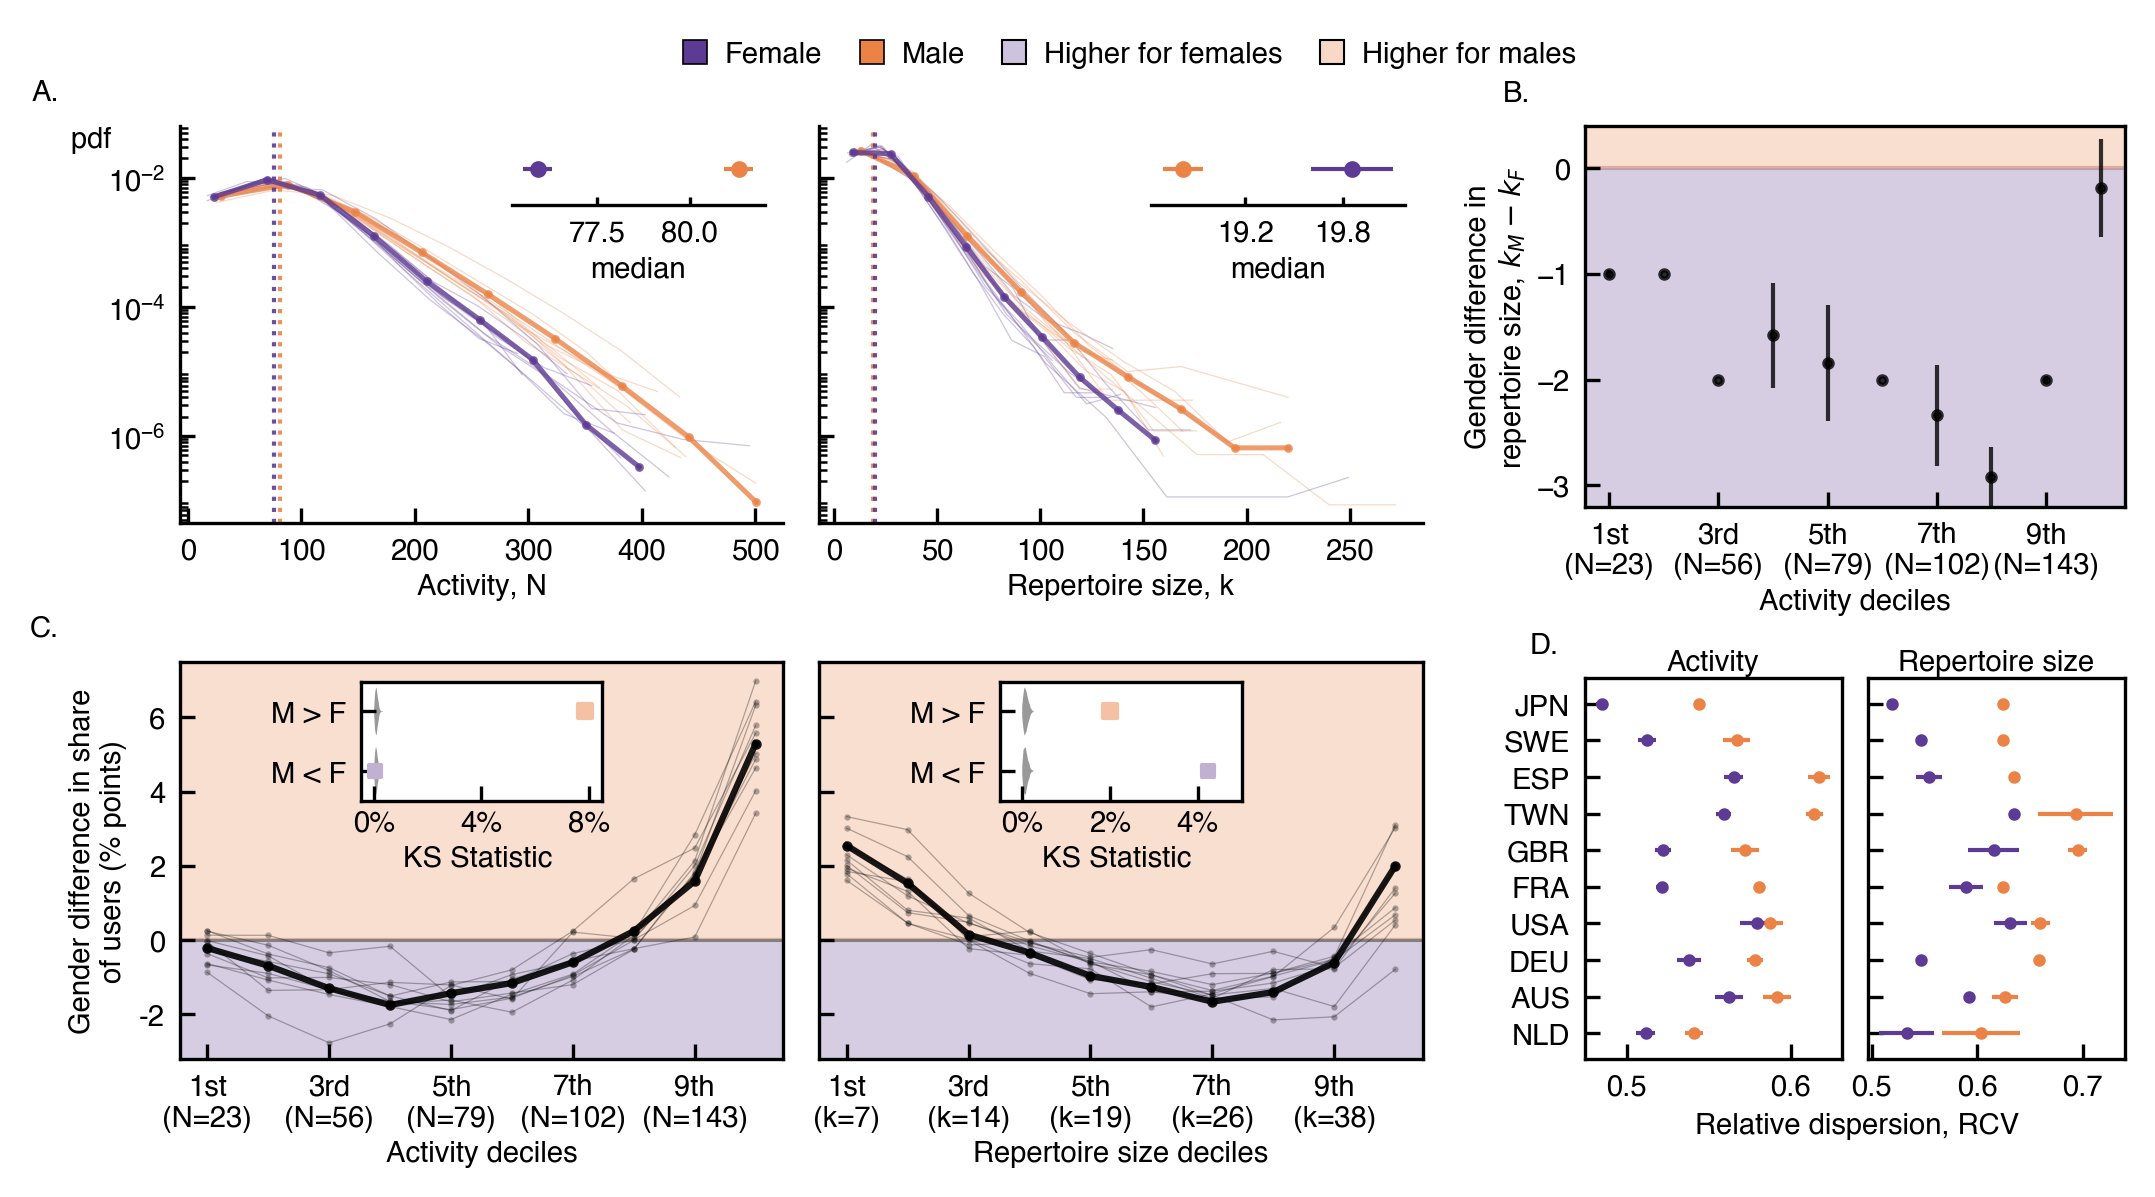

In [ ]:
## PANEL FOR FIGURE
fig = plt.figure(figsize=(18.3 * cm_to_inch, 10 * cm_to_inch))

gs = fig.add_gridspec(2, 3,  height_ratios=[1, 1], width_ratios=[1, 1, 1], wspace = 0.3, hspace=0.45)

main_gs = gs[:, :2].subgridspec(2, 2, wspace = 0.06, hspace=0.35)
ax_hist_N = fig.add_subplot(main_gs[0, 0])   
ax_hist_k = fig.add_subplot(main_gs[0, 1], sharey=ax_hist_N)   
ax_dec_N = fig.add_subplot(main_gs[1, 0])
ax_dec_k = fig.add_subplot(main_gs[1, 1], sharey=ax_dec_N)

ax_quant_Nk = fig.add_subplot(gs[0, 2])   

rcv_gs = gs[1, 2].subgridspec(1, 2, wspace = 0.1, hspace=0.1)
ax_rcv_N = fig.add_subplot(rcv_gs[0, 0])  
ax_rcv_k = fig.add_subplot(rcv_gs[0, 1], sharey=ax_rcv_N)  


ax_hist_N.text(-0.2, 1.05, "A.", transform=ax_hist_N.transAxes, va="bottom", ha="right")
ax_quant_Nk.text(-0.1, 1.05, "B.", transform=ax_quant_Nk.transAxes, va="bottom", ha="right")
ax_dec_N.text(-0.2, 1.05, "C.", transform=ax_dec_N.transAxes, va="bottom", ha="right")
ax_rcv_N.text(-0.1, 1.05, "D.", transform=ax_rcv_N.transAxes, va="bottom", ha="right")

## -- A. HISTOGRAMS + BS MEDIANS ------------------------
for ax, mlab in zip([ax_hist_N, ax_hist_k], MLAB):
    # Define inset
    x = 0.55
    y = 0.8
    ax_inset = ax.inset_axes([x, y, 1-x-0.03, 1-y-0.02], transform=ax.transAxes)
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)

    ## Plot by country
    for ctry in CTRY:
        for stat in GENDER:
            xx,yy = dic_hist[mlab][ctry][stat]
            ax.plot(xx, yy, color= COLOR[stat], alpha=0.3, lw = 0.3)

    ## Plot all countries
    ctry = 'all_ctry_wequalC' 
    for stat in GENDER:
        xx,yy = dic_hist[mlab][ctry][stat]
        ax.plot(xx, yy, color= COLOR[stat], alpha=0.8, marker ='.', markersize = 2.2, lw=1.2,)

        # plot median
        med = dic_bs_med[stat][mlab]['agg_equalweight']['med']
        ax.axvline(x=med, color= COLOR[stat], alpha=0.9, linestyle='dotted', lw = 1)

        ## fill inset with bs medians
        med = dic_bs_med[stat][mlab]['agg_equalweight']['med']
        se = dic_bs_med[stat][mlab]['agg_equalweight']['se']
        ax_inset.errorbar(med, 1, xerr=se, fmt='.', color=COLOR[stat])#, capsize=4, markersize=6, elinewidth=1.5)

    ax.set_yscale('log')
    ax.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10.0, numticks=4))
    ax.yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10.0, subs="auto", numticks=10))

    ax_inset.set_ylim(0.5, 1.5)
    ax_inset.xaxis.set_major_locator(plt.MaxNLocator(nbins=3, prune="both")) 
    ax_inset.spines.right.set_visible(False)
    ax_inset.spines.left.set_visible(False)
    ax_inset.spines.top.set_visible(False)
    ax_inset.tick_params(axis='y', left=False, labelleft=False)
    ax_inset.tick_params(axis='x', length = 2)
    ax_inset.set_xlabel('median', labelpad = 2)

# ax_hist_k.set_yticklabels([])
plt.setp(ax_hist_k.get_yticklabels(), visible=False)
ax_hist_N.text(-0.1, 1, 'pdf ', transform=ax_hist_N.transAxes, va="top", ha="right")
ax_hist_N.set_xlabel(dMLAB['visits'], labelpad=2)
ax_hist_k.set_xlabel(dMLAB['locations'], labelpad=2)


## -- B. GENDER DIFF in K by QUANT N ------------------------
ctry_agg = 'all_ctry_wequalC' 
df_Aq_pv = dic_Nkquant[ctry_agg]

## Sort quantiles
quantile_labels = ["1st", "2nd", "3rd"] + [f"{i}th" for i in range(4, 11)]
df_Aq_pv["deciles"] = pd.Categorical(df_Aq_pv["q10_visits_lab"], categories=quantile_labels, ordered=True)
quantile_values = dic_fracu['visits'][ctry_agg]['quantiles']

quant_xlab = {q:f"{q}\n({dMLAB['visits'][-1]}={int(v)})" for q,v in zip(quantile_labels, quantile_values[1:])}

df_Aq_pv["deciles_xlab"] = df_Aq_pv["deciles"].map(quant_xlab)

ax_quant_Nk.errorbar(y = df_Aq_pv["diff_med"], x = df_Aq_pv["deciles_xlab"], yerr=df_Aq_pv["diff_se"], 
                  fmt='o', color='k', alpha = 0.8, markersize = 2)

# ax_quant_Nk.axhline(y=0, color='k', alpha=1, linestyle='-', lw = 1)
ax_quant_Nk.set_yticks([0,-1,-2,-3][::-1])  
ax_quant_Nk.xaxis.set_major_locator(plt.MaxNLocator(nbins=5, prune="both"))

ax_quant_Nk.set_ylabel("Gender difference in\nrepertoire size, "+r"$k_M - k_F$", labelpad=2) #$\Delta k = 
ax_quant_Nk.set_xlabel("Activity deciles", labelpad=2)
# ax_quant_Nk.set_xlabel("N deciles", labelpad=2)

ax_quant_Nk.axhspan(-4, 0, xmin=0, xmax=10, color=COLOR["FEMALE"], alpha=0.25, zorder=-1)
ax_quant_Nk.axhspan(0, 0.65, xmin=0, xmax=10, color=COLOR["MALE"], alpha=0.25, zorder=-1)
ax_quant_Nk.set_ylim(-3.2, 0.4)



## -- C. GENDER DIFF by DECILES DIST and KS TEST ------------------------
ctry_agg = 'all_ctry_wequalC'  
for ax, mlab in zip([ax_dec_N, ax_dec_k], MLAB):
    
    ## -- Plot by country ----------------
    for ctry in CTRY + [ctry_agg]:
        data = dic_fracu[mlab][ctry]['res']
        df_fracu = pd.DataFrame.from_dict(data, orient= 'columns').reset_index().rename(columns={'index': 'deciles'})

        ## Sort quantiles
        quantile_labels = ["1st", "2nd", "3rd"] + [f"{i}th" for i in range(4, 11)]
        df_fracu["deciles"] = pd.Categorical(df_fracu["deciles"], categories=quantile_labels, ordered=True)
        quantile_values = dic_fracu[mlab][ctry_agg]['quantiles']
        quant_xlab = {q:f"{q}\n({dMLAB[mlab][-1]}={int(v)})" for q,v in zip(quantile_labels, quantile_values[1:])}
        # quant_xlab = {q:f"{int(v)}" for q,v in zip(quantile_labels, quantile_values[1:])}
        df_fracu["deciles_xlab"] = df_fracu["deciles"].map(quant_xlab)
        df_fracu = df_fracu.sort_values(by='deciles')

        ## Plot
        color = 'k' if ctry != ctry_agg else 'k' 
        alpha = 0.3 if ctry != ctry_agg else 0.9
        lw = 0.3 if ctry != ctry_agg else 1.5
        markersize = 1 if ctry != ctry_agg else 3
        df_fracu.plot(x='deciles_xlab', y='gap', ax=ax, kind='line', linestyle='-', marker='.', 
            lw=lw, markersize=markersize, color=color, alpha=alpha, legend=False, zorder=10)

        ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x*100:.0f}"))
    
    ax.set_xlabel(dMLAB[mlab][:-3] + ' deciles', labelpad=2)
    ax.axhline(0, color="grey", linestyle="-", linewidth=0.7, zorder=0)
    ax.axhspan(-0.04, 0, xmin=0, xmax=10, color=COLOR["FEMALE"], alpha=0.25, zorder=-1)
    ax.axhspan(0, 0.078, xmin=0, xmax=10, color=COLOR["MALE"], alpha=0.25, zorder=-1)
    ax.set_ylim(-0.032, 0.075)

    # -- Plot KS statistic in INSET ---------------- # NEEDS TO BE CORRECTED
    ## -- Define inset
    x = 0.3
    y = 0.65
    ax_inset = ax.inset_axes([x, y, 1-x*2, 1-y-0.05], transform=ax.transAxes)  #.08
    ctry_agg = 'all_ctry' 

    true_med_less = dic_KS[ctry_agg]['KS_true'][mlab]['less']['stat']
    true_med_greater = dic_KS[ctry_agg]['KS_true'][mlab]['greater']['stat']
    data_shuff_less = [val[mlab]['less']['stat'] for val in dic_KS[ctry_agg]['KS_shuff']]
    data_shuff_greater = [val[mlab]['greater']['stat'] for val in dic_KS[ctry_agg]['KS_shuff']]

    ax_inset.scatter(true_med_less, 1, color=COLOR['MALE light'], s=10, marker='s', zorder=10)
    ax_inset.scatter(true_med_greater, 0, color=COLOR['FEMALE light'], s=8, marker='s', zorder=11)

    ## -- Randomized baseline
    parts_1 = ax_inset.violinplot(data_shuff_less, positions=[1], widths=0.8, 
        showmeans=False, showmedians=False, showextrema=False, vert=False,
        )
    parts_2 = ax_inset.violinplot(data_shuff_greater, positions=[0], widths=0.8, 
        showmeans=False, showmedians=False, showextrema=False, vert=False,
        )
    for parts in [parts_1, parts_2]:
        for pc in parts['bodies']:
            pc.set_facecolor('grey')
            pc.set_alpha(0.8)

    ax_inset.set_xlim(-0.005, None)

    ax_inset.set_xlabel('KS Statistic ', labelpad=2)
    ax_inset.set_yticks([0, 1])
    ax_inset.set_yticklabels(['M < F', 'M > F', ])
    ax_inset.set_ylim(-0.5, 1.5)
    ax_inset.set_xlim(None, 0.085 if mlab == 'visits' else 0.05)    
    ax_inset.tick_params(axis='x', pad=2)
    ax_inset.xaxis.set_major_locator(plt.MaxNLocator(nbins=3, prune="both")) 
    ax_inset.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))


ax_dec_N.set_ylabel('Gender difference in share\nof users (% points)', labelpad=3)
plt.setp(ax_dec_k.get_yticklabels(), visible=False)


## -- D. GENDER GAP IN RCV ------------------------
metric = 'RCVM'
for ax, mlab in zip([ax_rcv_N, ax_rcv_k], MLAB):
    for i_buff,stat in enumerate(GENDER):
        for i, ctry in enumerate(CTRY):
            data = dic_bs_rcv[stat][metric][mlab][ctry]
            ax.errorbar(x=data['mean'], xerr=data['se'], y= i , marker='.', ms = 4, label=stat, color=COLOR[stat], alpha=1)

    ax.set_title(dMLAB[mlab][:-3], pad=2)

    ax.set_yticks(range(len(CTRY)))
    ax.set_yticklabels(CTRY)
    ax.set_ylim(-0.7, len(CTRY)-1+0.7) 
    ax.minorticks_off()    

plt.setp(ax_rcv_k.get_yticklabels(), visible=False)
ax_rcv_N.text(0.43,-0.14, 'Relative dispersion, RCV', transform=ax_rcv_N.transAxes, va="top", ha="left")


## -- LEGEND ------------------------
empty_handle = mpl.lines.Line2D([], [], color='none', marker='s', markersize=4, linestyle='None', label="    "*4)

handle_gen = [mpl.lines.Line2D([], [], color=COLOR[gen], marker='s', markersize=4, linestyle='None', 
    markeredgecolor='black', markeredgewidth=0.4, label=gen.capitalize()) for gen in GENDER[::-1]]

handle_background = [mpl.lines.Line2D([], [], markerfacecolor= mpl.colors.to_rgba(COLOR[gen], alpha=0.3), marker='s', markersize=4, linestyle='None', 
    markeredgecolor='black', markeredgewidth=0.5, label="Higher for " + gen.lower() +'s') for gen in GENDER[::-1]]

handles = handle_gen + handle_background

leg = ax_hist_k.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.08),
    frameon=False,
    ncol=4,
    fontsize=fs,
    handletextpad=0.02,
    columnspacing=0.7, 
    markerscale=1.4,
)
leg._legend_title_box.sep = 20


fig.subplots_adjust(left=0.08, right=0.98, top=0.9, bottom=0.11)
plt.savefig(output_fig_path + "fig_1.pdf", bbox_inches=None)
plt.show()

## SUPPLEMENTARY MATERIALS

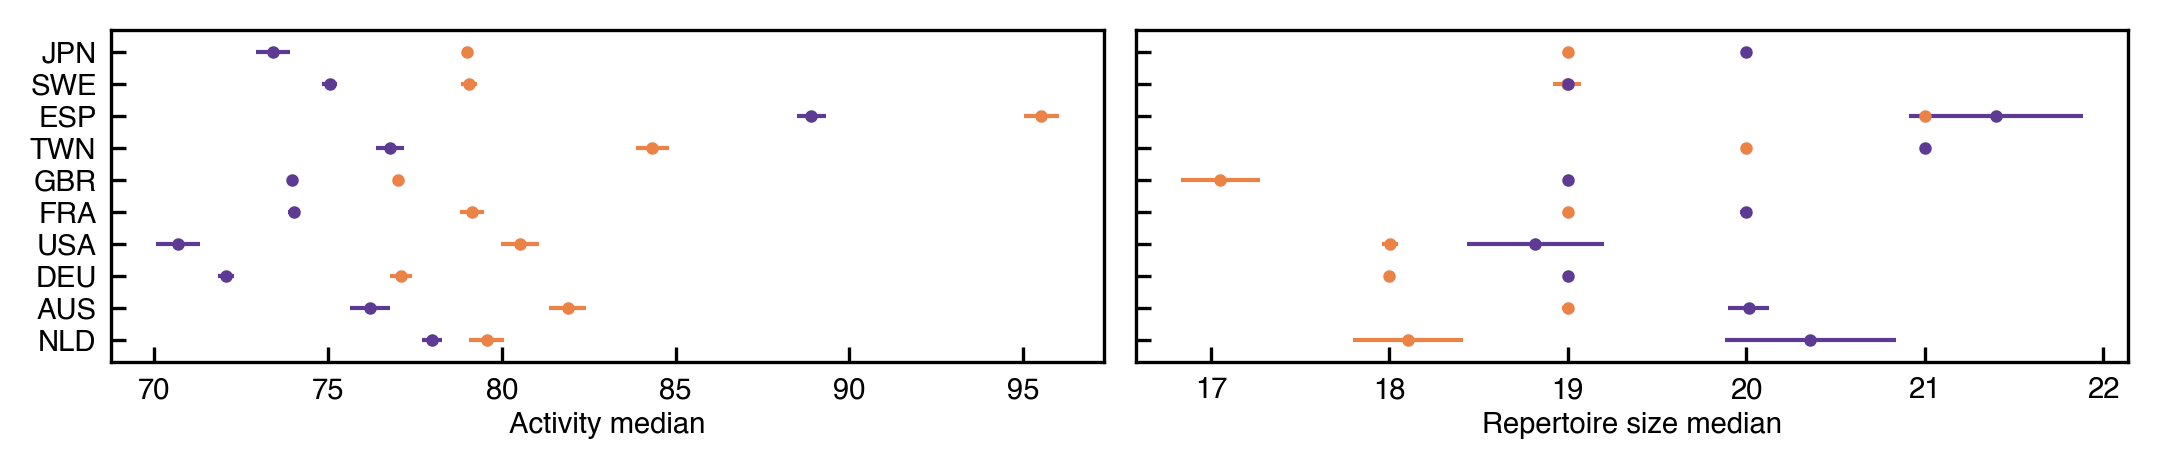

In [10]:
## S1.1 BOOTSRAP MEDIANS BY COUNTRY
fig, (ax_N, ax_k) = plt.subplots(1,2, figsize=(18.3 * cm_to_inch, 4 * cm_to_inch), sharey=True)

for ax, mlab in zip([ax_N, ax_k], MLAB):
    for i_buff,stat in enumerate(GENDER):
        for i, ctry in enumerate(CTRY):
            data = dic_bs_med[stat][mlab][ctry]
            ax.errorbar(x=data['med'], xerr=data['se'], y= i, marker='.', ms = 4, label=stat, color=COLOR[stat], alpha=1)

    ax.set_xlabel(dMLAB[mlab][:-3] + ' median', labelpad=2)

    ax.set_yticks(range(len(CTRY)))
    ax.set_yticklabels(CTRY)
    ax.set_ylim(-0.7, len(CTRY)-1+0.7) 

plt.tight_layout()
plt.savefig(output_fig_path + "si_bsmed_ctry.pdf", bbox_inches="tight")
plt.show()

In [11]:
percent_labels = [i for i in range(1, 11, 1)]
quantile_labels = ["1st", "2nd", "3rd"] + [f"{i}th" for i in range(4, 11)]
perc2quant = {p:q for p,q in zip(percent_labels, quantile_labels)}

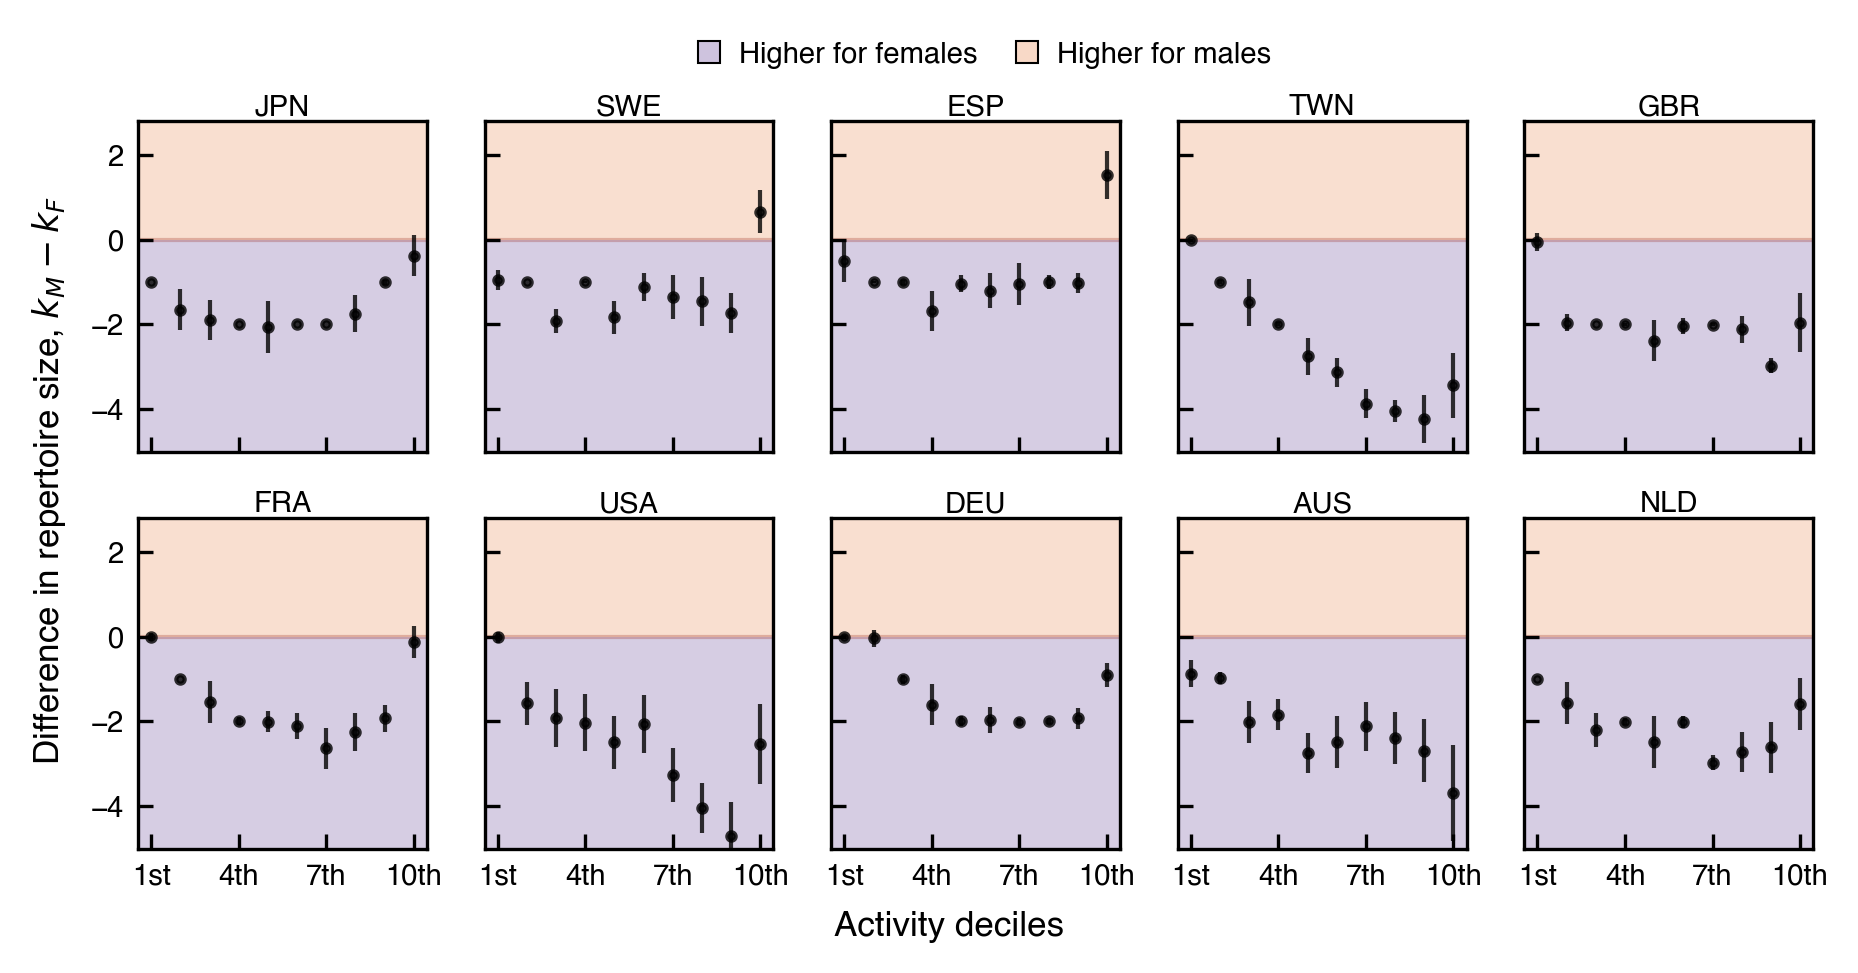

In [12]:
## S1.2. DIFFERNCE in K by QUANTILE BY COUNTRY
fig, axs = plt.subplots(2,5,  figsize=(18.3 * cm_to_inch, 8 * cm_to_inch), sharey = True, sharex=True)

for ax,ctry in zip(axs.flatten(), CTRY[::-1]):
    df_Aq_pv = dic_Nkquant[ctry]
    ax.errorbar(y = df_Aq_pv["diff_med"], x = df_Aq_pv["q10_visits"], yerr=df_Aq_pv["diff_se"], 
                  fmt='o', color='k', alpha = 0.8, markersize = 2)
    
    QUANTILES = sorted(set(df_Aq_pv["q10_visits"]))[::3]
    QUANTILES_LAB = [perc2quant[q] for q in QUANTILES]
    ax.set_xticks(QUANTILES) 
    ax.set_xticklabels(QUANTILES_LAB) 
    ax.set_title(ctry, pad=1)

    # ax.set_yticks([0,-1,-2][::-1])  
    # ax.axhline(y=0, color='k', alpha=1, linestyle='-', lw = 1)
    ax.axhspan(-6, 0, xmin=0, xmax=10, color=COLOR["FEMALE"], alpha=0.25, zorder=-1)
    ax.axhspan(0, 3, xmin=0, xmax=10, color=COLOR["MALE"], alpha=0.25, zorder=-1)
    ax.set_ylim(-5, 2.8)


## -- LEGEND ------------------------
handle_background = [mpl.lines.Line2D([], [], markerfacecolor= mpl.colors.to_rgba(COLOR[gen], alpha=0.3), marker='s', markersize=4, linestyle='None', 
    markeredgecolor='black', markeredgewidth=0.5, label="Higher for " + gen.lower() +'s') for gen in GENDER[::-1]]

handles = handle_background

leg = axs[0,2].legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.08),
    frameon=False,
    ncol=2,
    fontsize=fs,
    handletextpad=0.02,
    columnspacing=0.7, 
    markerscale=1.3,
)
leg._legend_title_box.sep = 20



fig.supylabel("Difference in repertoire size, "+r"$k_M - k_F$", x=0.075) #$\Delta k = 
fig.supxlabel("Activity deciles")
plt.savefig(output_fig_path + "si_Nkquant_ctry.pdf", bbox_inches="tight")
plt.show()

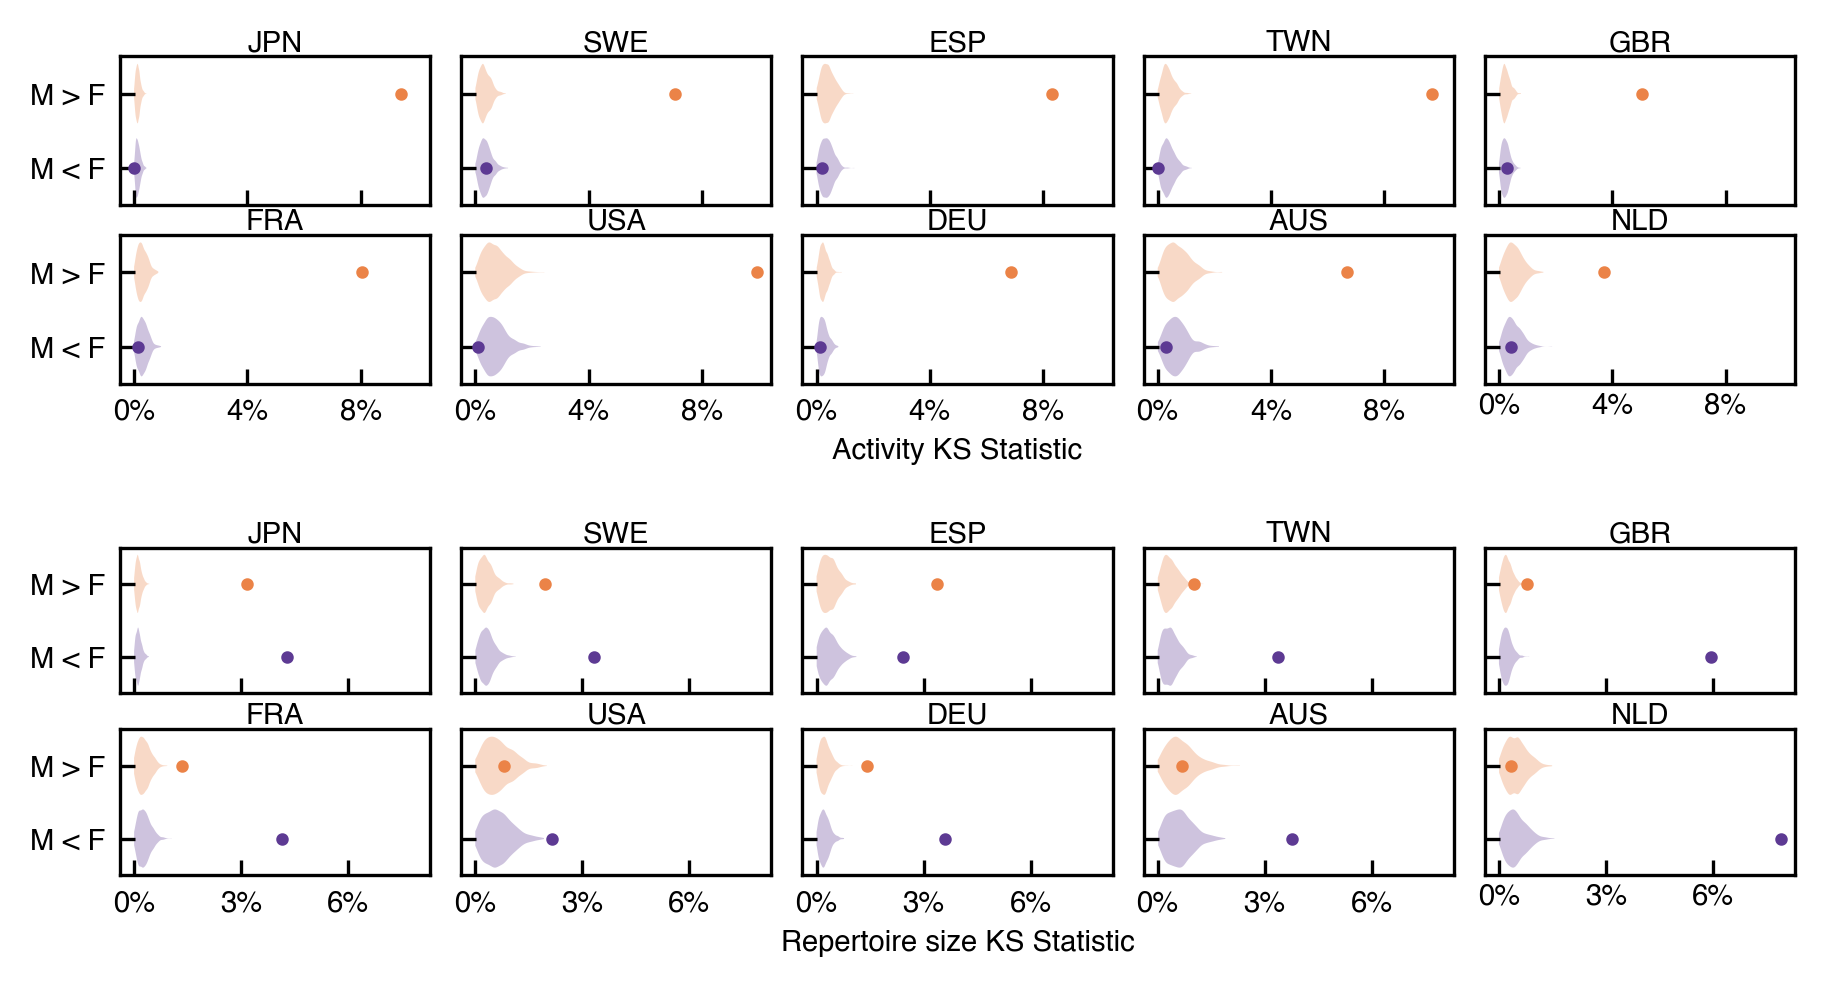

In [ ]:
## S4.1 KS TEST by COUNTRY
fig = plt.figure(figsize=(18.3 * cm_to_inch, 9 * cm_to_inch), constrained_layout=False)

# Outer grid: controls the BIG gap between the two 2×5 grids
outer = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.5)  

# Inner grids: control spacing *within* each 2×5 grid
top_spec = outer[0].subgridspec(2, 5, wspace=0.1, hspace=0.2)            
bot_spec = outer[1].subgridspec(2, 5, wspace=0.1, hspace=0.25)

# Create axes arrays for each grid
axs_N = top_spec.subplots(sharex=True, sharey=True)
axs_k = bot_spec.subplots(sharex=True, sharey=True)


for axs, mlab in zip([axs_N, axs_k], MLAB):
    for ax, ctry in zip(axs.ravel(), CTRY[::-1]):
        true_med_less = dic_KS[ctry]['KS_true'][mlab]['less']['stat']
        data_shuff_less = [val[mlab]['less']['stat'] for val in dic_KS[ctry]['KS_shuff']]

        true_med_greater = dic_KS[ctry]['KS_true'][mlab]['greater']['stat']
        data_shuff_greater = [val[mlab]['greater']['stat'] for val in dic_KS[ctry]['KS_shuff']]

        ax.scatter(true_med_less, 1, color=COLOR['MALE'], s=4, marker='o', zorder=10)
        ax.scatter(true_med_greater, 0, color=COLOR['FEMALE'], s=4, marker='o', zorder=11)

        ## -- Randomized baseline
        parts_1 = ax.violinplot(data_shuff_less, positions=[1], widths=0.8, 
            showmeans=False, showmedians=False, showextrema=False, vert=False,
            )
        parts_2 = ax.violinplot(data_shuff_greater, positions=[0], widths=0.8, 
            showmeans=False, showmedians=False, showextrema=False, vert=False,
            )
        for parts in [parts_1, parts_2]:
            for pc in parts['bodies']:
                # pc.set_facecolor('grey')
                pc.set_facecolor(COLOR['FEMALE' if parts == parts_2 else 'MALE'])
                pc.set_alpha(0.3)

        ax.set_title(ctry, pad=1)

    ax.tick_params(axis='x', pad=2)
    ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=3, prune="both")) 
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))

for axs, mlab in zip([axs_N, axs_k], MLAB):
    axs[0,0].set_yticks([0, 1])
    axs[0,0].set_yticklabels(['M < F', 'M > F', ])
    axs[0,0].set_ylim(-0.5, 1.5)
    axs[1,2].set_xlabel(f'{dMLAB[mlab][:-3]} KS Statistic', labelpad=3)


plt.savefig(output_fig_path + "si_KS_ctry.pdf", bbox_inches="tight")
plt.show()

In [14]:
# ── 1. Input data ───────────────────────────────────────────────────────
fname = "fig1_si_fract_users_ra.pkl"
with open(input_fig_path + fname, "rb") as f:
    grid_pct = pickle.load(f)

fname = "fig1_si_fract_users_gender_delta_ra.pkl"
with open(input_fig_path + fname, "rb") as f:
    grid_delta = pickle.load(f)

In [15]:
# ── 2. Segment boxes ───────────────────────────────────────────────────────
segments = {
    "inactive": (1, 3, 1, 3),
    "moderate": (4, 7, 4, 7),
    "active":   (8, 10, 8, 10),
}

def draw_box(ax, seg, color="black", lw=0.8):
    r_lo, r_hi, c_lo, c_hi = seg
    ax.add_patch(Rectangle(
        (c_lo - 1.5, r_lo - 1.5),
        c_hi - c_lo + 1, r_hi - r_lo + 1,
        linewidth=lw, edgecolor=color, facecolor="none"
    ))


In [17]:
from matplotlib.patches import Rectangle

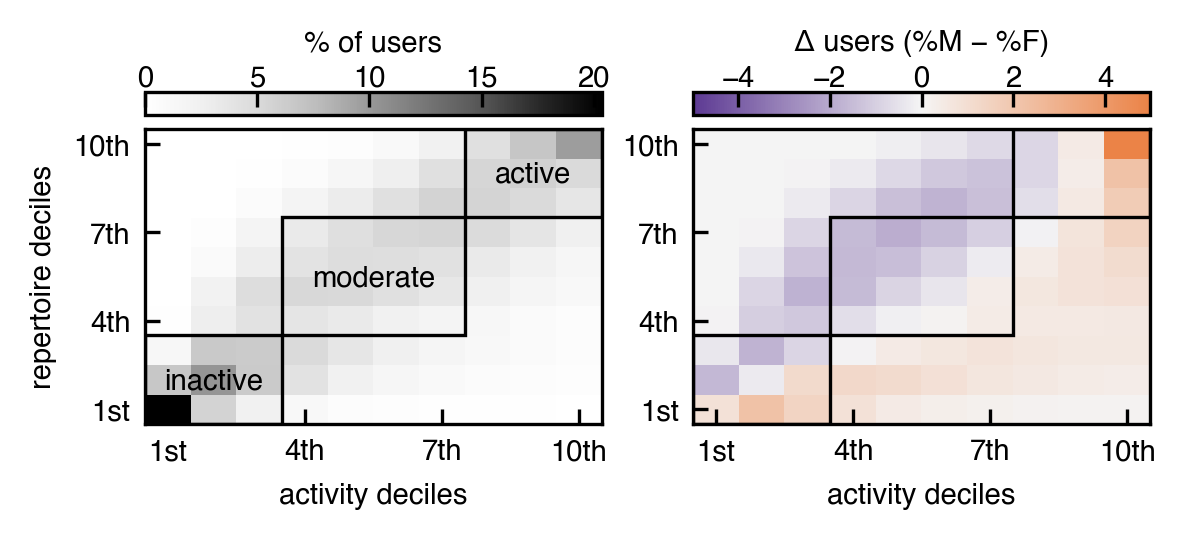

In [19]:
# ── 3. Plot ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18.3 * cm_to_inch * 0.6, 4 * cm_to_inch))

# Only show 1st, 4th, 7th, 10th decile labels
sparse_ticks  = [0, 3, 6, 9]          # 0-indexed positions
sparse_labels = ["1st", "4th", "7th", "10th"]

# — Left: % of users —
im1 = ax1.imshow(grid_pct, origin="lower", cmap="Greys",
                 vmin=0, vmax=grid_pct.max(),
                 extent=[-0.5, 9.5, -0.5, 9.5], aspect="auto")

ax1.set_xticks(sparse_ticks); ax1.set_xticklabels(sparse_labels, fontsize=7)
ax1.set_yticks(sparse_ticks); ax1.set_yticklabels(sparse_labels, fontsize=7)
ax1.set_xlabel("activity deciles")
ax1.set_ylabel("repertoire deciles")

cbar1 = fig.colorbar(im1, ax=ax1, location="top", orientation="horizontal",
                     fraction=0.15, pad=0.04, anchor=(0.5, 0.0), panchor=(0.5, 1.0))

cbar1.set_label("% of users", labelpad=3.5)
cbar1.ax.xaxis.set_label_position("top")
cbar1.ax.xaxis.tick_top()
cbar1.ax.tick_params(pad=0)
cbar1.ax.set_position([ax1.get_position().x0,        # match subplot x0
                        cbar1.ax.get_position().y0,
                        ax1.get_position().width,     # match subplot width
                        cbar1.ax.get_position().height])

cbar1.ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=100, decimals=0))

# Segment boxes + labels
box_labels = {"inactive": (1, 0.5), "moderate": (4.5, 4), "active": (8, 7.5)}
for name, seg in segments.items():
    draw_box(ax1, seg)
    ax1.text(*box_labels[name], name, va="bottom", ha="center", fontsize=7)

# — Right: Δ users (%M − %F) —
vmax = np.abs(grid_delta).max()
cmap_div = mcolors.LinearSegmentedColormap.from_list(
    "bwr_custom", [COLOR['FEMALE'], "whitesmoke", COLOR['MALE']])

im2 = ax2.imshow(grid_delta, origin="lower", cmap=cmap_div,
                 vmin=-vmax, vmax=vmax,
                 extent=[-0.5, 9.5, -0.5, 9.5], aspect="auto")

ax2.set_xticks(sparse_ticks); ax2.set_xticklabels(sparse_labels, fontsize=7)
ax2.set_yticks(sparse_ticks); ax2.set_yticklabels(sparse_labels, fontsize=7)
ax2.set_xlabel("activity deciles")

cbar2 = fig.colorbar(im2, ax=ax2, location="top", orientation="horizontal",
                     fraction=0.15, pad=0.04, anchor=(0.5, 0.0), panchor=(0.5, 1.0))

cbar2.set_label("Δ users (%M − %F)", labelpad=3.5)
cbar2.ax.xaxis.set_label_position("top")
cbar2.ax.xaxis.tick_top()
cbar2.ax.tick_params(pad =0)
cbar2.ax.set_position([ax2.get_position().x0,
                        cbar2.ax.get_position().y0,
                        ax2.get_position().width,
                        cbar2.ax.get_position().height])

for name, seg in segments.items():
    draw_box(ax2, seg)
plt.savefig(output_fig_path + "si_fract_users_AMI_MF.pdf", bbox_inches=None) #"tight"
plt.show()

----